# PopOut: MCTS and ID3 Decision Trees

**Authors:** Miguel Almeida, Francisco Passos, Pedro Resende  
**Course:** Artificial Intelligence 2025/2026, FCUP

This notebook documents our implementation and evaluation of two AI agents for the PopOut variant of Connect-4: a Monte Carlo Tree Search agent with UCT, and an ID3 decision tree trained on MCTS self-play games. We optimised the MCTS via tournament-based hyperparameter sweeps, used it to generate a labelled self-play dataset, and trained the decision tree on that data.

In [1]:
import csv
import inspect
import json
from pathlib import Path

import numpy as np
import pandas as pd

from ai.mcts import MCTS
from game.board import COLS, ROWS, PopOutBoard

## 1. Introduction

PopOut is a Connect-4 variant that introduces a *pop* move — removing one of your own discs from the bottom row, dropping every disc above it down by one — together with three special rules that disambiguate simultaneous wins, full-board states, and threefold repetitions.

We implement two agents for it: a **Monte Carlo Tree Search** (MCTS) agent for adversarial search, and an **ID3 decision tree** for supervised learning trained on labelled (state, move) pairs harvested from MCTS self-play.

The assignment forbids `scikit-learn` for the decision tree (so ID3 is implemented from scratch) and the engine must support human-vs-human, human-vs-computer, and computer-vs-computer modes.

§2 describes the game environment and §3 the MCTS implementation. Later sections cover MCTS hyperparameter tuning, the self-play dataset, the ID3 algorithm, and a final ID3-vs-MCTS comparison.

## 2. Game environment

**Board representation.** The state is a `(6, 7)` matrix of `int8` values drawn from `{0, 1, 2}` (empty, player 1, player 2), with row 0 at the top and row 5 at the bottom where pops occur. The current player and a list of state hashes (for repetition detection) complete the state.

**Move space.** Each turn offers up to 14 actions: 7 drop columns (legal whenever the column is not full) plus up to 7 pop columns (legal only when the bottom cell of that column belongs to the player to move).

**Three special rules.** *Simultaneous four-in-a-rows* — if a pop creates a 4-in-a-row for both players, the popper wins and the opponent's line is ignored. *Full board* — if no drop is legal, the player to move chooses between popping and declaring a draw. *Threefold repetition* — if a position recurs three times, either player may claim a draw.

**Public API.** `PopOutBoard` exposes `get_valid_moves()`, `make_move(kind, col)`, and `is_terminal()`; the MCTS additionally uses `clone()` for simulations and `get_state_hash()` for repetition bookkeeping.

In [2]:
example = PopOutBoard()
example.make_move("drop", 3)
example.make_move("drop", 3)
example.make_move("drop", 4)

# PopOutBoard does not implement __str__; render inline.
symbols = {0: ".", 1: "X", 2: "O"}
for row in example.board:
    print("".join(symbols[int(v)] for v in row))

.......
.......
.......
.......
...O...
...XX..


## 3. Monte Carlo Tree Search

MCTS plans by repeatedly executing four phases: **selection** descends from the root, choosing the most promising child by UCT; **expansion** adds one (or more) children for an untried move; **simulation** runs a random rollout from the new leaf to a terminal state; **backpropagation** updates the visit count and accumulated reward on every node along the traversed path.

### UCT selection

Children are ranked by the standard UCT score

$$\mathrm{UCT}(c) \;=\; \bar{X}_c \;+\; c_\text{explore} \sqrt{\frac{\ln N_p}{N_c}}$$

where $\bar{X}_c = W_c / N_c$ is the mean reward of child $c$, $N_p$ is the parent's visit count, $N_c$ the child's, and $c_\text{explore}$ the exploration weight (default $\sqrt{2}$). The first term *exploits* known-good children; the second *explores* under-visited ones.

### Adversarial perspective

Rewards are accumulated in the **root player's** perspective and never flipped during backpropagation. At nodes where the *opponent* is to move, however, the exploitation term is mirrored — the opponent picks the move that *minimises* our expected return, so UCT uses $1 - \bar{X}_c$ as the exploitation component for such children. This was a non-trivial correction during development; without the flip, the agent picks the worst move for itself at every opponent ply and plays catastrophically.

### Terminal subtree propagation

Once an entire subtree below a node is provably win, loss, or draw, the node is marked *terminal* and skipped by selection on future iterations. A *forcing-child* shortcut additionally resolves a node as soon as the player to move has a single proven-winning child, without waiting for siblings to be explored. Both behaviours avoid wasted rollouts in regions of the tree whose value is already known.

### Variants implemented

The assignment asks us to look beyond the textbook recipe; we expose two orthogonal knobs:

- **`num_children_to_expand`** ($k$): expand up to $k$ untried children per visit to a partially-expanded node (default $k=1$). Larger $k$ front-loads breadth at the cost of less deep exploitation early in the search.
- **`uct_variant`**: classic **UCB1** (above) or **UCB1-Tuned**, which replaces the constant exploration term with a variance-aware bound $\sqrt{(\ln N_p / N_c) \cdot \min(\tfrac{1}{4}, V_c)}$, where $V_c$ is the empirical reward variance of $c$ plus a $\sqrt{2 \ln N_p / N_c}$ regulariser and $\tfrac{1}{4}$ caps the maximum variance attainable by a reward in $[0, 1]$. The `exploration_weight` argument is ignored in this mode.

### Numba JIT-compiled rollout

The random rollout in `ai/rollout_numba.py` is decorated with `@njit(cache=True)`. Compiling it ahead of time brings each rollout from a few milliseconds in pure Python down to tens of microseconds; the cache is written to disk on first import so subsequent runs skip the 10–30 s compile cost. This is what makes 20 000+ iterations per move tractable on commodity hardware and underpins the tournament-based hyperparameter sweeps presented later in the notebook.

In [3]:
print(inspect.getsource(MCTS._uct_score))

    def _uct_score(self, child: MCTSNode, parent: MCTSNode) -> float:
        """UCT score from the perspective of the player to move at ``parent``.

        Rewards are stored in the root player's perspective. When the parent
        node is at the opponent's turn, the opponent maximises its own reward,
        which is ``1 - mean`` in the root-perspective accounting. The
        exploration term is symmetric and never flipped, regardless of
        variant.

        Dispatches on ``self.uct_variant``:

        * ``"ucb1"`` — classic UCT with the constant exploration weight
          ``self.exploration_weight``.
        * ``"ucb1_tuned"`` — variance-aware bound of Auer, Cesa-Bianchi &
          Fischer (2002). The exploration term scales with the empirical
          variance of the child's rewards, clamped above by ``1/4`` (the
          theoretical maximum variance of a reward in ``[0, 1]``). The
          ``exploration_weight`` argument is ignored in this mode.
        """
        i

The `if self.uct_variant == "ucb1":` branch above implements the classic UCT exploration term; the `else` branch computes the variance-aware UCB1-Tuned bound in the same function.

In [4]:
import matplotlib.pyplot as plt


def wilson_ci(wins: int, n: int, z: float = 1.96) -> tuple[float, float]:
    """Two-sided Wilson 95% confidence interval for a binomial proportion."""
    if n == 0:
        return (0.0, 0.0)
    p_hat = wins / n
    denom = 1 + z * z / n
    center = (p_hat + z * z / (2 * n)) / denom
    half = z * np.sqrt(p_hat * (1 - p_hat) / n + z * z / (4 * n * n)) / denom
    return (center - half, center + half)


def load_matchups(csv_path: str) -> pd.DataFrame:
    """Load a tournament CSV and attach Wilson 95% CI columns for A's winrate."""
    df = pd.read_csv(Path("data/tournaments") / csv_path)
    cis = df.apply(lambda r: wilson_ci(r.a_wins, r.total_games), axis=1)
    df = df.assign(
        a_ci_low=[c[0] for c in cis],
        a_ci_high=[c[1] for c in cis],
    )
    return df


DATA_DIR = Path("data")


## 4. MCTS hyperparameter tuning

Hyperparameters were swept via head-to-head tournaments between candidate configurations. Every matchup is 100 games (except where explicitly noted), with player 1 / player 2 alternated 50/50 between the two configurations so that first-mover advantage cancels. `base_seed=0` throughout, so every result is bit-for-bit reproducible. Confidence intervals are Wilson 95 %.

We sweep four hyperparameters: number of iterations per move, the UCT exploration weight `c`, the expansion fan-out `num_children_to_expand` (`k`), and the UCT variant (UCB1 vs UCB1-Tuned).


### 4.1 Iterations

Stronger players use more rollouts per move. The chain below pits successive doublings (and one decuple, 20 000 → 100 000) against each other.


In [5]:
iter_df = load_matchups("tournament_iterations.csv")
display(
    iter_df[["matchup_name", "total_games", "a_wins", "b_wins",
             "a_winrate", "a_ci_low", "a_ci_high"]]
    .rename(columns={"a_winrate": "A wr", "a_ci_low": "A CI low",
                     "a_ci_high": "A CI high"})
)


,matchup_name,total_games,a_wins,b_wins,A wr,A CI low,A CI high
0,iter_200_vs_1000,100,25,75,0.25,0.175451,0.343046
1,iter_1000_vs_5000,100,23,77,0.23,0.158432,0.321546
2,iter_5000_vs_20000,100,34,66,0.34,0.254614,0.437225
3,iter_20000_vs_100000,100,40,60,0.40,0.309400,0.497999


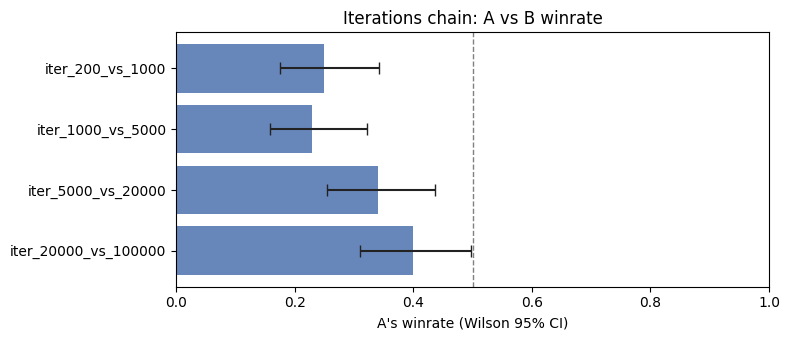

In [6]:
fig, ax = plt.subplots(figsize=(8, 3.5))
labels = iter_df['matchup_name'].tolist()
winrates = iter_df['a_winrate'].to_numpy()
lows = iter_df['a_ci_low'].to_numpy()
highs = iter_df['a_ci_high'].to_numpy()
xerr = np.vstack([winrates - lows, highs - winrates])
y = np.arange(len(labels))
ax.barh(y, winrates, xerr=xerr, color='#4C72B0', alpha=0.85, capsize=4, ecolor='#222')
ax.axvline(0.5, color='grey', linestyle='--', linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_xlabel("A's winrate (Wilson 95% CI)")
ax.set_title('Iterations chain: A vs B winrate')
fig.tight_layout()
plt.show()

**Iter commentary.** Each step in the chain pits a configuration against one with more rollouts. 
The lower-iter side loses every matchup, but the *margin* of defeat shrinks: 200 vs 1 000 is a 
75-25 rout; 1 000 vs 5 000 stays similar (77-23); 5 000 vs 20 000 narrows to 66-34; the final 
step 20 000 vs 100 000 finishes at only 60-40, with the loser's CI brushing 0.5. Diminishing 
returns are clearly setting in. We **adopt 20 000 iterations** as the operating point for 
downstream sweeps: it is strong enough that the next quintupling barely separates from noise, 
while remaining cheap enough to run hundreds of games per matchup.


### 4.2 Exploration weight (c)

The UCT exploration term is scaled by a constant `c`. Larger `c` pushes the tree to explore 
less-visited children; smaller `c` exploits the current best estimate. The textbook default is 
$c=\sqrt{2}$, but the optimum depends on the game. We sweep a chain of doublings and then 
extend the chain past $\sqrt{2}$ to see where it plateaus.


In [7]:
c_df = pd.concat([
    load_matchups('tournament_c.csv'),
    load_matchups('tournament_c_extended.csv'),
], ignore_index=True)
display(
    c_df[['matchup_name', 'total_games', 'a_wins', 'b_wins',
          'a_winrate', 'a_ci_low', 'a_ci_high']]
    .rename(columns={'a_winrate': 'A wr', 'a_ci_low': 'A CI low',
                     'a_ci_high': 'A CI high'})
)

,matchup_name,total_games,a_wins,b_wins,A wr,A CI low,A CI high
0,c_0.1_vs_0.25,100,10,90,0.10,0.055229,0.174367
1,c_0.25_vs_0.5,100,31,69,0.31,0.227796,0.406262
2,c_0.5_vs_sqrt2,100,41,59,0.41,0.318672,0.507987
3,c_sqrt2_vs_2.0,100,46,54,0.46,0.365606,0.557353
4,c_2.0_vs_3.0,100,52,48,0.52,0.423164,0.615356
5,c_3.0_vs_4.0,100,59,41,0.59,0.492013,0.681328
6,c_4.0_vs_5.0,100,50,50,0.50,0.403830,0.596170


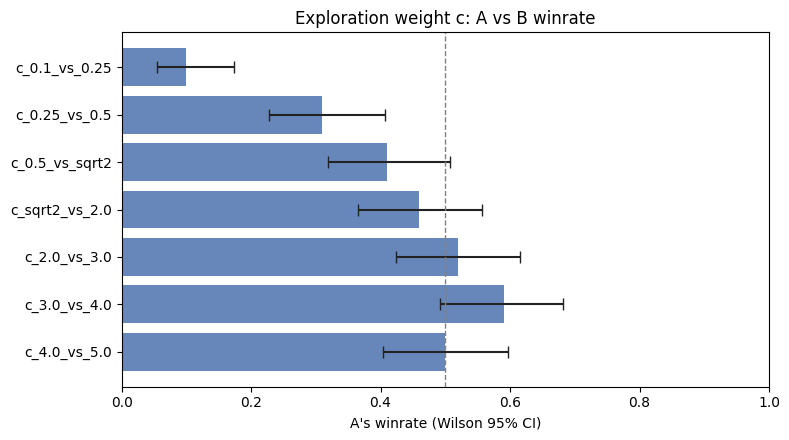

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
labels = c_df['matchup_name'].tolist()
winrates = c_df['a_winrate'].to_numpy()
lows = c_df['a_ci_low'].to_numpy()
highs = c_df['a_ci_high'].to_numpy()
xerr = np.vstack([winrates - lows, highs - winrates])
y = np.arange(len(labels))
ax.barh(y, winrates, xerr=xerr, color='#4C72B0', alpha=0.85, capsize=4, ecolor='#222')
ax.axvline(0.5, color='grey', linestyle='--', linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_xlabel("A's winrate (Wilson 95% CI)")
ax.set_title('Exploration weight c: A vs B winrate')
fig.tight_layout()
plt.show()

**c commentary.** Walking the chain: $c=0.1$ collapses against $c=0.25$ (10-90); $c=0.25$ loses 
to $c=0.5$ (31-69); $c=0.5$ loses to $\sqrt{2}$ (41-59); $\sqrt{2}$ loses to $c=2.0$ (46-54, 
CI [0.36, 0.56] — marginal but consistent with the trend). Above $c=2.0$ the chain plateaus: 
$c=2.0$ vs $c=3.0$ ties within noise (52-48), $c=3.0$ vs $c=4.0$ swings back to the smaller 
value (59-41), and $c=4.0$ vs $c=5.0$ is a dead heat (50-50). The optimum sits in roughly 
$[2, 3]$. **We adopt $c = 2.0$** because it is the only value head-to-head-validated in two 
independent matchups (vs $\sqrt{2}$, won; vs $c=3.0$, tied).


### 4.3 Fan-out (k)

`num_children_to_expand` (k) controls how many children are expanded per call to the expansion 
phase. The default `k=1` adds one child per visit (textbook MCTS); larger `k` front-loads the 
tree's breadth at the cost of fewer deep visits per child. We sweep a chain and then resolve 
the inconclusive result with a direct k=1 vs k=7 matchup.


In [9]:
k_chain = load_matchups('tournament_num_children.csv')
k_direct = load_matchups('tournament_k_1_vs_7.csv')
print('Chain (k=1 → 3 → 7 → 10 → 14, c=√2, 20 000 iter):')
display(
    k_chain[['matchup_name', 'total_games', 'a_wins', 'b_wins',
             'a_winrate', 'a_ci_low', 'a_ci_high']]
    .rename(columns={'a_winrate': 'A wr', 'a_ci_low': 'A CI low',
                     'a_ci_high': 'A CI high'})
)
print('Direct k=1 vs k=7 (c=√2, 20 000 iter):')
display(
    k_direct[['matchup_name', 'total_games', 'a_wins', 'b_wins',
              'a_winrate', 'a_ci_low', 'a_ci_high']]
    .rename(columns={'a_winrate': 'A wr', 'a_ci_low': 'A CI low',
                     'a_ci_high': 'A CI high'})
)

Chain (k=1 → 3 → 7 → 10 → 14, c=√2, 20 000 iter):


,matchup_name,total_games,a_wins,b_wins,A wr,A CI low,A CI high
0,k_1_vs_3,100,57,43,0.57,0.472152,0.662669
1,k_3_vs_7,100,52,48,0.52,0.423164,0.615356
2,k_7_vs_10,100,59,41,0.59,0.492013,0.681328
3,k_10_vs_14,100,50,50,0.50,0.403830,0.596170


Direct k=1 vs k=7 (c=√2, 20 000 iter):


,matchup_name,total_games,a_wins,b_wins,A wr,A CI low,A CI high
0,k_1_vs_7,100,68,32,0.68,0.583372,0.76331


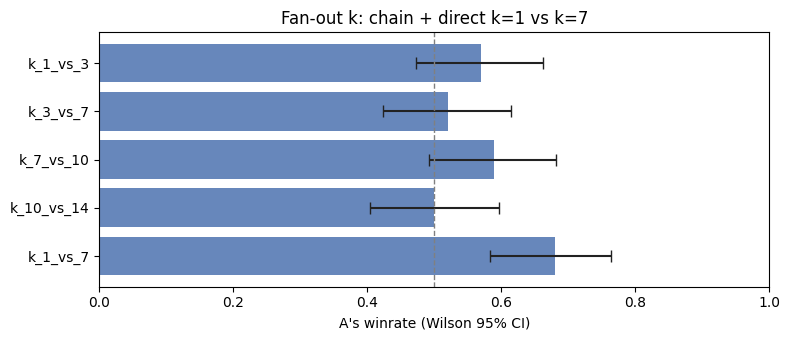

In [10]:
k_df = pd.concat([k_chain, k_direct], ignore_index=True)
fig, ax = plt.subplots(figsize=(8, 3.5))
labels = k_df['matchup_name'].tolist()
winrates = k_df['a_winrate'].to_numpy()
lows = k_df['a_ci_low'].to_numpy()
highs = k_df['a_ci_high'].to_numpy()
xerr = np.vstack([winrates - lows, highs - winrates])
y = np.arange(len(labels))
ax.barh(y, winrates, xerr=xerr, color='#4C72B0', alpha=0.85, capsize=4, ecolor='#222')
ax.axvline(0.5, color='grey', linestyle='--', linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_xlabel("A's winrate (Wilson 95% CI)")
ax.set_title('Fan-out k: chain + direct k=1 vs k=7')
fig.tight_layout()
plt.show()

**k commentary.** The chain alone is inconclusive: every step finishes near 50-50 with CIs 
that bracket the dashed line (k=1 vs k=3 at 0.57, k=3 vs k=7 at 0.52, k=7 vs k=10 at 0.59, 
k=10 vs k=14 at 0.50). Each individual step is consistent with noise. The direct k=1 vs k=7 
matchup resolves the question: **k=1 wins 68-32**, Wilson 95 % CI ≈ [0.58, 0.76], comfortably 
excluding 0.5. Spending the iteration budget on deeper visits beats spreading it across more 
siblings at the same depth. **We adopt $k = 1$.**


### 4.4 UCT variant (UCB1 vs UCB1-Tuned)

UCB1-Tuned is a variance-aware refinement of the UCB1 selection rule that replaces the 
fixed exploration constant with a per-arm variance bound. When `uct_variant='ucb1_tuned'` the 
`exploration_weight` argument is ignored. We compare the two variants first at a cheap budget 
(1 000 iter, $c=\sqrt{2}$, $k=1$) and then at the production budget (20 000 iter, $c=2.0$, $k=1$).


In [11]:
uct_prelim = load_matchups('tournament_uct.csv')
uct_final = load_matchups('tournament_final_variants.csv')
print('Preliminary (1 000 iter, c=√2):')
display(
    uct_prelim[['matchup_name', 'total_games', 'a_wins', 'b_wins',
                'a_winrate', 'a_ci_low', 'a_ci_high']]
    .rename(columns={'a_winrate': 'A wr', 'a_ci_low': 'A CI low',
                     'a_ci_high': 'A CI high'})
)
print('Final budget (20 000 iter, c=2.0, k=1):')
display(
    uct_final[['matchup_name', 'total_games', 'a_wins', 'b_wins',
               'a_winrate', 'a_ci_low', 'a_ci_high']]
    .rename(columns={'a_winrate': 'A wr', 'a_ci_low': 'A CI low',
                     'a_ci_high': 'A CI high'})
)

Preliminary (1 000 iter, c=√2):


,matchup_name,total_games,a_wins,b_wins,A wr,A CI low,A CI high
0,ucb1_vs_ucb1_tuned,100,40,60,0.4,0.3094,0.497999


Final budget (20 000 iter, c=2.0, k=1):


,matchup_name,total_games,a_wins,b_wins,A wr,A CI low,A CI high
0,ucb1_optimal_vs_ucb1_tuned_optimal,100,60,40,0.6,0.502001,0.6906


**UCT-variant commentary.** At 1 000 iter the two variants are statistically indistinguishable 
— UCB1 wins 40-60 with CI ≈ [0.31, 0.50], i.e. the CI for UCB1's winrate just touches the 0.5 
line, leaving the comparison inconclusive in either direction. At the production budget (20 000 
iter, $c=2.0$, $k=1$) UCB1 wins 60-40 with CI ≈ [0.50, 0.69]: the lower bound barely excludes 
0.5. The reading leans UCB1 but it is fragile, so **§5.1 revisits the matchup at $N=400$** to 
tighten the interval before committing.


### 4.5 Final operating point

Pulling the four sub-sweeps together:

| Parameter | Adopted value | Source |
|---|---|---|
| `iterations` | 20 000 | §4.1 |
| `exploration_weight` (c) | 2.0 | §4.2 |
| `num_children_to_expand` (k) | 1 | §4.3 |
| `uct_variant` | `ucb1` | §4.4 (revisited in §5.1) |

These values define the *optimised MCTS* used to (i) generate the self-play dataset in §6 and 
(ii) face the baseline in the final evaluation in §5.2. The baseline retained for comparison is 
the textbook configuration we started from: 5 000 iter, $c=\sqrt{2}$, $k=1$, UCB1.


## 5. Final MCTS evaluation

Two questions remain open after §4:

1. The §4.4 reading that UCB1 beats UCB1-Tuned at the production budget rests on a single 
100-game matchup with a CI that only just excludes 0.5. Does the result survive at $N=400$?
2. How much does the *optimised MCTS* actually improve over the textbook *baseline* (5 000 iter, 
$c=\sqrt{2}$, $k=1$, UCB1)?

§5.1 tightens the UCB1 vs UCB1-Tuned interval; §5.2 measures both optimised variants against 
the baseline and surfaces a non-transitivity finding; §5.3 picks the final adopted agent.


### 5.1 N = 400 confirmation: UCB1 vs UCB1-Tuned

Same configuration as §4.4's production matchup (20 000 iter, $c=2.0$, $k=1$), scaled from 
100 to 400 games. The Wilson CI half-width shrinks roughly by $\sqrt{4}=2\times$, so we 
expect a $\pm 0.05$-wide interval instead of $\pm 0.10$.


In [12]:
uct_n400 = load_matchups('tournament_final_variants_n400.csv')
display(
    uct_n400[['matchup_name', 'total_games', 'a_wins', 'b_wins',
              'a_winrate', 'a_ci_low', 'a_ci_high']]
    .rename(columns={'a_winrate': 'A wr', 'a_ci_low': 'A CI low',
                     'a_ci_high': 'A CI high'})
)

,matchup_name,total_games,a_wins,b_wins,A wr,A CI low,A CI high
0,ucb1_optimal_vs_ucb1_tuned_optimal_n400,400,237,163,0.5925,0.543687,0.639553


**N=400 commentary.** UCB1 wins **237 / 400 = 59.25 %** against UCB1-Tuned, Wilson 95 % CI 
$\approx [54.4\%, 64.0\%]$. The lower bound now sits well above 0.5; the 100-game reading was 
not a fluke. **UCB1 is the statistically stronger variant at our operating point.**


### 5.2 Optimised MCTS vs baseline

Both optimised variants (UCB1 and UCB1-Tuned, each at 20 000 iter, $c=2.0$, $k=1$) face the 
textbook baseline (5 000 iter, $c=\sqrt{2}$, $k=1$, UCB1). 100 games each, P1/P2 alternated 50/50.


In [13]:
vs_base = load_matchups('tournament_final_vs_baseline.csv')
display(
    vs_base[['matchup_name', 'total_games', 'a_wins', 'b_wins',
             'a_winrate', 'a_ci_low', 'a_ci_high']]
    .rename(columns={'a_winrate': 'A wr', 'a_ci_low': 'A CI low',
                     'a_ci_high': 'A CI high'})
)

,matchup_name,total_games,a_wins,b_wins,A wr,A CI low,A CI high
0,ucb1_optimal_vs_baseline,100,66,34,0.66,0.562775,0.745386
1,ucb1_tuned_optimal_vs_baseline,100,70,30,0.70,0.604150,0.781052


**The observation.** Both optimised variants beat the baseline decisively: UCB1 wins 66-34, 
UCB1-Tuned wins 70-30. On record-against-the-common-opponent, **UCB1-Tuned looks slightly 
stronger**. Yet head-to-head (§5.1), **UCB1 wins 237-163 over UCB1-Tuned**. The variant with 
the worse score against the baseline wins the direct match. This is *non-transitivity in policy 
space* — a documented phenomenon in adversarial game-playing AI (cf. Balduzzi et al., 2019, 
*Open-ended Learning in Symmetric Zero-Sum Games*).

**The explanation.** The P1/P2 breakdown below shows the mechanism. Against the baseline, 
UCB1 plays *spikily* — 47/50 = 94 % as P1, 19/50 = 38 % as P2 — exploiting first-mover 
advantage hard and collapsing without it. UCB1-Tuned plays *symmetrically* — 41/50 = 82 % as 
P1, 29/50 = 58 % as P2 — its variance-aware exploration term keeps it defensively solid in 
both seats. The weak baseline cannot punish UCB1's lopsided style; the strong UCB1-Tuned, 
facing UCB1 head-to-head, splits the seats and turns the matchup into a contest UCB1 wins on 
raw exploitation power. Higher *average* play strength against a fixed opponent does not 
imply higher head-to-head strength against a peer.


In [14]:
rows = []
for src, df in [('vs_baseline', vs_base), ('head_to_head', uct_n400)]:
    for _, r in df.iterrows():
        half = r['total_games'] / 2
        rows.append({
            'source': src,
            'matchup': r['matchup_name'],
            'A_as_P1': r['a_wins_as_p1'] / half,
            'A_as_P2': r['a_wins_as_p2'] / half,
            'B_as_P1': r['b_wins_as_p1'] / half,
            'B_as_P2': r['b_wins_as_p2'] / half,
        })
p1p2 = pd.DataFrame(rows)
display(p1p2.round(2))

,source,matchup,A_as_P1,A_as_P2,B_as_P1,B_as_P2
0,vs_baseline,ucb1_optimal_vs_baseline,0.94,0.38,0.62,0.06
1,vs_baseline,ucb1_tuned_optimal_vs_baseline,0.82,0.58,0.42,0.18
2,head_to_head,ucb1_optimal_vs_ucb1_tuned_optimal_n400,0.86,0.32,0.68,0.14


### 5.3 Adopted agent

Head-to-head record is the academic standard for ranking adversarial agents (the FIDE/Elo 
tradition, AlphaGo's training tournaments, the autoML and evolutionary-play literatures all 
use direct matchups). On that criterion §5.1 picks UCB1 unambiguously. We therefore adopt

> **Optimised MCTS = UCB1, 20 000 iter, $c=2.0$, $k=1$**

as the production agent. It is the configuration used to play out the self-play games in §6 
and the opponent against which the trained decision trees will be evaluated in §10.


## 6. Self-play dataset generation

The ID3 trees in §7 onwards are trained on (state, move) pairs harvested from MCTS-vs-MCTS 
self-play. We generate **two** datasets so §8-§10 can compare what "learning from a weaker 
teacher" looks like against "learning from a stronger teacher":

- **Baseline dataset:** the teacher is the textbook MCTS (5 000 iter, $c=\sqrt{2}$, $k=1$, 
UCB1) — the agent we started from before any tuning.
- **Optimised dataset (the 150 k file used downstream):** the teacher is the §5.3 
configuration (20 000 iter, $c=2.0$, $k=1$, UCB1).

**Move-selection policy during data collection.** Pure greedy self-play would visit very few 
distinct states, so we soften the teacher with two perturbations borrowed from AlphaZero-style 
expert-iteration work (Anthony et al., 2017, *Thinking Fast and Slow with Deep Learning and 
Tree Search*):

- $\varepsilon = 0.25$: with probability $\varepsilon$ pick a uniformly-random legal move 
instead of the MCTS choice — guarantees coverage of states the optimiser would never reach.
- `opening_max = 12`: for the first 12 plies of every game pick a *visit-weighted* random move 
among MCTS's children rather than the argmax — diversifies openings without going completely 
off-policy in the midgame.

**CSV schema (47 columns):**

- `cell_r{0..5}_c{0..6}` — 42 raw board cells, $\{0, 1, 2\}$ for empty / P1 / P2.
- `to_move` — whose turn it is, $\{1, 2\}$.
- `move_count` — plies played so far.
- `last_move_col` — last column touched (`-1` for the first ply).
- `last_move_type` — `drop` / `pop` / `none`.
- `class` — the MCTS-chosen move, one of $\{$`drop_0..drop_6`, `pop_0..pop_6`$\}$.

§8 derives an additional 8 binned features from these raw columns; the trees consume the binned 
form, not the raw cells.


### 6.1 Reproducibility and parallel generation

The dataset took ~30 CPU-hours to generate. We needed it to be (i) bit-identical across reruns 
and (ii) safely parallelisable across machines, because we generated the 150 k optimised 
dataset by farming chunks out to ~15 cloud instances plus one local PC. Both properties fall 
out of one design choice: deriving a deterministic per-game master seed from the global 
`base_seed` and the game index.


In [15]:
from scripts.generate_dataset import _derive_seed
print(inspect.getsource(_derive_seed))

def _derive_seed(base_seed: int, game_index: int) -> int:
    """Per-game master seed.

    Independent of worker count so the dataset is the same whether the
    pool has 1 or 32 workers.
    """
    return (base_seed * 1_000_003 + game_index) & 0x7FFF_FFFF



Two consequences fall out:

1. **Reproducibility.** Same `base_seed` $\rightarrow$ same per-game seed $\rightarrow$ same 
rollouts $\rightarrow$ byte-identical CSV. We re-ran the 150 k generation once during 
debugging and the output matched the original to the byte.
2. **Multi-machine parallelism without correctness risk.** Because the seed depends only on the 
*game index*, not on the worker that happens to draw that game, the merged output of $N$ 
machines splitting the index range is bit-identical to a single-machine run. We exploited this 
to split the 150 k optimised dataset into 18 chunks across ~15 cloud instances plus one local 
PC, then concatenated the per-chunk CSVs at the end.


### 6.2 Dataset size and class distribution

We load only the `class` column to inspect the label distribution without paying for the 47-column 
decode of 1.4 M rows.


In [16]:
classes = pd.read_csv(DATA_DIR / 'popout_dataset_150k.csv', usecols=['class'])
class_counts = classes['class'].value_counts().sort_index()
total = int(class_counts.sum())
imbalance_ratio = float(class_counts.max() / class_counts.min())
print(f'Total labelled positions: {total:,}')
print(f'Classes present: {class_counts.shape[0]} / 14')
print(f'Max-to-min count ratio: {imbalance_ratio:.1f}')
display(class_counts.to_frame('count'))

Total labelled positions: 1,464,670
Classes present: 14 / 14
Max-to-min count ratio: 49.3


,count
class,
drop_0,72852
drop_1,151766
drop_2,256966
drop_3,388722
drop_4,256139
drop_5,151589
drop_6,72377
pop_0,7991
pop_1,15079


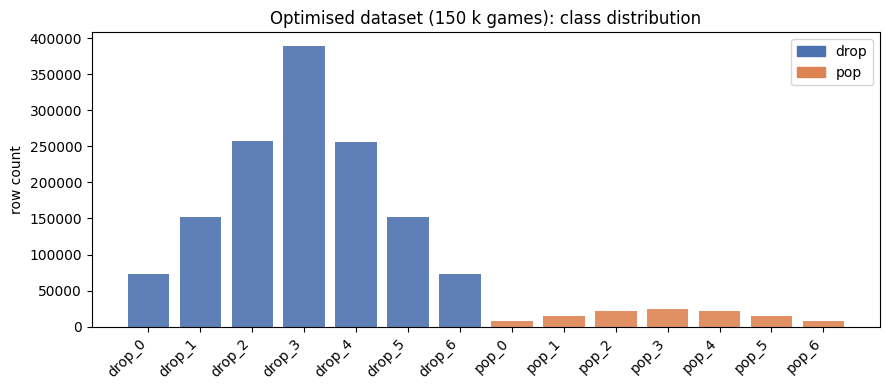

In [17]:
fig, ax = plt.subplots(figsize=(9, 4))
labels = class_counts.index.tolist()
counts = class_counts.to_numpy()
colors = ['#4C72B0' if l.startswith('drop_') else '#DD8452' for l in labels]
x = np.arange(len(labels))
ax.bar(x, counts, color=colors, alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylabel('row count')
ax.set_title('Optimised dataset (150 k games): class distribution')
# Legend handles
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#4C72B0', label='drop'),
                   Patch(color='#DD8452', label='pop')], loc='upper right')
fig.tight_layout()
plt.show()

**Class-distribution commentary.** The dataset contains **1,464,670 labelled positions** across 
all 14 possible moves. Drops dominate — they account for ~92 % of rows — because every ply of 
the early game adds another piece without removing one, and the pop move only becomes 
attractive once both stacks have grown. Within the drops, **the centre column `drop_3` is the 
modal label at 388 722 rows**, reflecting the well-known centre-of-the-board preference in 
Connect-4-like games. The rarest class is **`pop_6` (7 886 rows)**, giving a max-to-min ratio of 
**~49×**. This imbalance directly motivates the `cap_N` undersampling sweep in §8.4: without it, 
the ID3 tree degenerates into predicting `drop_3` for almost everything.


## 7. ID3 algorithm and Iris warm-up

ID3 is a top-down recursive decision-tree builder that picks the feature with the highest Information Gain at every node. We implement it from scratch — scikit-learn's tree primitives are forbidden by the assignment — in [`ai/id3.py`](ai/id3.py). The same algorithm drives both the Iris sanity check below and the PopOut pipeline that follows in §8.

### 7.1 Algorithm

Information theory underpins the splitting rule. For a label distribution $y$ over classes $c$ with empirical probabilities $p_c$, the **entropy** of $y$ and the **Information Gain** of splitting on feature $f$ (with values $v$) are

$$H(y) \;=\; -\sum_c p_c \log_2 p_c, \qquad IG(y, f) \;=\; H(y) \;-\; \sum_v \frac{|y_v|}{|y|}\, H(y_v).$$

The recursion is straightforward: at each node, choose the feature with the highest $IG$, partition the data into one child per unique feature value, and recurse on each partition. Pre-pruning stops the recursion when (i) the partition is class-pure, (ii) the candidate-feature list is empty, (iii) the depth reaches `max_depth`, or (iv) the partition has fewer than `min_samples` rows — in which cases the node becomes a leaf labelled with the majority class.

In [18]:
from ai.id3 import id3, entropy, information_gain

print(inspect.getsource(entropy))
print(inspect.getsource(information_gain))

def entropy(y: pd.Series) -> float:
    """Shannon entropy (base 2) of the class distribution in ``y``.

    Returns ``0.0`` for an empty series or a pure series.
    """
    if len(y) == 0:
        return 0.0
    counts = y.value_counts().values
    probs = counts / counts.sum()
    probs = probs[probs > 0]
    return float(-np.sum(probs * np.log2(probs)))

def information_gain(X: pd.DataFrame, y: pd.Series, feature: str) -> float:
    """Information gain obtained by splitting ``X``/``y`` on ``feature``.

    Multi-way split over the unique values of ``feature`` — the classical
    ID3 formulation.
    """
    total_n = len(y)
    if total_n == 0:
        return 0.0
    weighted = sum(
        (len(subset) / total_n) * entropy(subset)
        for val in X[feature].unique()
        for subset in [y[X[feature] == val]]
    )
    return entropy(y) - weighted



### 7.2 Iris warm-up

The assignment requires Iris as a sanity check on the ID3 implementation. Iris is a canonical three-class problem (setosa, versicolor, virginica) with four continuous features; on a sound implementation it should hit $\geq 90\%$ test accuracy out of the box.

ID3 only splits on categorical features, so each numeric column is discretised into four equal-frequency quantile buckets (`q1`..`q4`) before training. This replaced an earlier IG-threshold-per-feature scheme that capped accuracy at $\sim 67\%$: that scheme perfectly separated setosa using `petal_length` or `petal_width`, but reduced every other feature to a binary indicator that could not distinguish versicolor from virginica.

In [19]:
from ai.dt_pipeline import run_iris_demo

iris_tree, iris_acc = run_iris_demo()

IRIS DATASET  WARM-UP

Loaded Iris: 150 rows × 5 columns
Classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
Features: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

Discretising features into 4 equal-frequency quantile buckets:
  sepal_length          ->  4 buckets: ['q1', 'q2', 'q3', 'q4']
  sepal_width           ->  4 buckets: ['q1', 'q2', 'q3', 'q4']
  petal_length          ->  4 buckets: ['q1', 'q2', 'q3', 'q4']
  petal_width           ->  4 buckets: ['q1', 'q2', 'q3', 'q4']

Train: 120 rows  |  Test: 30 rows

Training ID3 on Iris...

Iris test accuracy: 93.33%

Iris Decision Tree (full — small enough to display):
------------------------------------------------------------
└── [petal_length]  (majority: Iris-setosa)
    ├── = q3
    │   └── [petal_width]  (majority: Iris-versicolor)
    │       ├── = q2
    │       │   └── LEAF: Iris-versicolor
    │       ├── = q3
    │       │   └── [sepal_length]  (majority: Iris-versicolor)
    │       │       ├── = q

The iris tree reaches $\sim 93\%$ test accuracy at depth 4 ($\approx 19$ nodes). It is small enough to display in full — every leaf prints its predicted class — and the result confirms that the ID3 implementation in `ai/id3.py` behaves as expected before we turn it loose on the much harder PopOut task.

## 8. PopOut preprocessing and the D1 validation sweep

Iris confirmed the algorithm; we now apply the same ID3 to the PopOut self-play dataset built from MCTS rollouts (§5–6). The data path has four stages — **balance classes → stratified split → bin continuous features → train** — implemented in [`ai/dt_pipeline.py`](ai/dt_pipeline.py). The four parameters that govern those stages (`cap` for balancing; `max_depth` and `min_samples` for pre-pruning; the choice to balance at all) were validated empirically in sub-experiment D1; the tables below summarise the relevant figures from sub-experiment D1.

### 8.1 Class imbalance and balance strategy

MCTS-generated training rows are dominated by `drop_3` — the centre column is overwhelmingly the best opening, and most replies. The raw class distribution reported in §6.2 shows an imbalance ratio of roughly $49\times$ between the largest class (`drop_3`) and the smallest POP class. Training ID3 directly on this distribution lets the tree maximise accuracy by predicting `drop_3` everywhere and learn essentially nothing about POP moves.

We mitigate this with **undersampling by cap**: every class with more than `cap` rows is randomly downsampled to `cap`, and under-represented classes (the seven POP classes) are kept whole. The trade-off is visible: smaller `cap` ⇒ better class balance but less data overall; larger `cap` ⇒ more data but stronger bias toward `drop_3`. The exact `cap` value is one of the parameters validated in the D1 sweep below.

### 8.2 Stratified train/val/test split

We use a **stratified 72 / 8 / 20** train / validation / test split, implemented in `ai.dt_pipeline.stratified_split` with pure NumPy and pandas (no scikit-learn). The split is nested: a first 80 / 20 stratified pass produces the test set, then a second 90 / 10 pass on the 80% produces the validation set, yielding the final 72 / 8 / 20 of the balanced dataset.

Stratification ensures that every class is proportionally represented in each fold, which matters here because some POP classes are small enough that an unstratified split could put a class entirely in train or entirely in test. `seed=42` throughout for reproducibility — every figure and table below comes from the same set of permutations.

### 8.3 Feature binning

ID3 in its classical form requires categorical features; the dataset has three continuous columns — `move_count`, `own_pieces_bottom_row`, `opp_pieces_bottom_row` — that need discretisation. We use **hand-designed bins** keyed to meaningful game phases: early/mid/late/endgame for `move_count`, and low/mid/high for the two piece counters. The other 42 features are the 6×7 cell occupancies, which are already categorical with values in $\{0, 1, 2\}$ and need no binning.

In [20]:
from ai.dt_pipeline import POPOUT_BIN_DEFINITIONS
import pprint

pprint.pprint(POPOUT_BIN_DEFINITIONS)

{'move_count': {'bins': [-1, 10, 20, 30, 100],
                'labels': ['early', 'mid', 'late', 'endgame']},
 'opp_pieces_bottom_row': {'bins': [-1, 1, 3, 7],
                           'labels': ['low', 'mid', 'high']},
 'own_pieces_bottom_row': {'bins': [-1, 1, 3, 7],
                           'labels': ['low', 'mid', 'high']}}


### 8.4 D1 validation sweep — motivation

The four pipeline parameters above were initially fixed ad-hoc in an earlier iteration of the project (`cap=50_000`, `max_depth=15`, `min_samples=20`, balancing on). The D1 sub-experiment validates them empirically with two sweeps run on **both** the baseline dataset (`popout_200k.csv`, 5 k MCTS iterations, $c=\sqrt{2}$) and the optimised dataset (`popout_dataset_150k.csv`, 20 k iterations, $c=2$, UCB1):

- **Sub-experiment A — cap sweep.** `cap ∈ {10 000, 30 000, 50 000, 100 000, 200 000, None}` at fixed `(max_depth=15, min_samples=20)`. Six trees per dataset.
- **Sub-experiment B — pre-pruning grid.** At each dataset's best cap, `max_depth ∈ {5, 8, 10, 15, 20}` × `min_samples ∈ {10, 20, 50, 100}` = 20 trees per dataset.
- **Cross-dataset transferability.** Each dataset's best recipe is applied to the other dataset's val set, to check whether a *shared* recipe is methodologically justifiable for Phase 2.

Selection metric is `val_macro_f1` (macro-averaged F1 over all 14 classes) — accuracy alone would reward predicting `drop_3` and hide the imbalance problem. Tie-break: smaller `n_nodes` (Occam). All four CSVs below were produced by `scripts/sweep_id3.py` (`seed=42`).

In [21]:
cap_baseline = pd.read_csv(DATA_DIR / "sweeps" / "sweep_cap_baseline.csv")
cap_optimised = pd.read_csv(DATA_DIR / "sweeps" / "sweep_cap_optimised.csv")

cap_cols = ['cap', 'val_macro_f1', 'val_accuracy', 'pop_recall', 'n_nodes']
print("Sub-A — baseline dataset (cap sweep at max_depth=15, min_samples=20):")
display(cap_baseline[cap_cols])
print("Sub-A — optimised dataset (cap sweep at max_depth=15, min_samples=20):")
display(cap_optimised[cap_cols])

Sub-A — baseline dataset (cap sweep at max_depth=15, min_samples=20):


,cap,val_macro_f1,val_accuracy,pop_recall,n_nodes
0,10000.0,0.417216,0.421832,0.541691,15834
1,30000.0,0.482687,0.482046,0.579979,39704
2,50000.0,0.487081,0.477347,0.543487,55834
3,100000.0,0.487102,0.492746,0.473436,91996
4,200000.0,0.483798,0.521833,0.425424,144827
5,NaN,0.463453,0.563859,0.375260,197659


Sub-A — optimised dataset (cap sweep at max_depth=15, min_samples=20):


,cap,val_macro_f1,val_accuracy,pop_recall,n_nodes
0,10000.0,0.439578,0.442727,0.542437,15333
1,30000.0,0.477498,0.477349,0.531832,36180
2,50000.0,0.482643,0.487438,0.484511,51817
3,100000.0,0.485526,0.518937,0.422561,83367
4,200000.0,0.464893,0.548391,0.367141,123629
5,NaN,0.456917,0.589606,0.340538,148079


**Cap commentary.** The best cap differs between datasets — `cap=50 000` on baseline (val macro-F1 = 0.4871) and `cap=100 000` on optimised (val macro-F1 = 0.4855). Both sit in the same $\sim 0.48$ band, with `pop_recall` peaking around `cap=30 000` and degrading sharply at `cap=200 000` and `None`: at those sizes the trees over-fit `drop_3` and lose the POP signal entirely (`pop_recall` collapses from $\sim 0.54$ to $\sim 0.37$). The `n_nodes` column tells the same story — uncapped trees roughly triple in size for a $\sim 0.02$ drop in macro-F1, which is exactly the over-fitting fingerprint we want to avoid.

In [22]:
grid_baseline = pd.read_csv(DATA_DIR / "sweeps" / "sweep_grid_baseline.csv")
grid_optimised = pd.read_csv(DATA_DIR / "sweeps" / "sweep_grid_optimised.csv")

print("Sub-B — baseline dataset (val_macro_f1 by max_depth × min_samples, cap=50_000):")
display(
    grid_baseline.pivot(
        index="max_depth", columns="min_samples", values="val_macro_f1",
    ).round(4)
)
print("Sub-B — optimised dataset (val_macro_f1 by max_depth × min_samples, cap=100_000):")
display(
    grid_optimised.pivot(
        index="max_depth", columns="min_samples", values="val_macro_f1",
    ).round(4)
)

Sub-B — baseline dataset (val_macro_f1 by max_depth × min_samples, cap=50_000):


min_samples,10,20,50,100
max_depth,,,,
5,0.2349,0.2349,0.2350,0.2350
8,0.3958,0.3959,0.3958,0.3942
10,0.4585,0.4586,0.4535,0.4404
15,0.4835,0.4871,0.4722,0.4485
20,0.4841,0.4873,0.4722,0.4485


Sub-B — optimised dataset (val_macro_f1 by max_depth × min_samples, cap=100_000):


min_samples,10,20,50,100
max_depth,,,,
5,0.1993,0.1993,0.1993,0.1996
8,0.3702,0.3701,0.3705,0.3684
10,0.4475,0.4465,0.4436,0.4298
15,0.4894,0.4855,0.4672,0.4425
20,0.4901,0.4856,0.4672,0.4425


**Grid commentary.** Deeper trees combined with smaller `min_samples` win consistently on both datasets. The optimised dataset peaks at `(max_depth=20, min_samples=10)` with val macro-F1 = 0.4901; the baseline peaks at `(max_depth=20, min_samples=20)` with 0.4873. The colleague's ad-hoc `(max_depth=15, min_samples=20)` from the original pipeline was a defensible guess — both datasets place it inside a competitive band — but the empirical optimum is $\approx 0.02$–$0.04$ p.p. macro-F1 above it. The depth-5 row is dramatically worse on both datasets (`val_macro_f1` $\approx 0.23$ on baseline, $\approx 0.20$ on optimised), confirming that 5 levels of splits are simply not enough to express the move-prediction problem.

### 8.5 Cross-dataset transferability

Phase 2 (§9 onwards) compares the baseline and optimised trees head-to-head, so we cannot afford to use *different* hyperparameters for each tree — doing so would conflate two effects (dataset quality vs. hyperparameter quality) we want to measure separately. To pick a single, defensible recipe we apply each dataset's own best recipe to the *other* dataset's validation set and measure the gap.

The result: the optimised recipe transplanted to the baseline loses **0.34 p.p.** macro-F1 against the baseline's own optimum; the baseline recipe transplanted to the optimised loses **0.75 p.p.** Both gaps are well below the 2 p.p. threshold for **Outcome X** — recipes transfer well — so a shared recipe is methodologically justified. We adopt the more portable of the two, namely the optimised dataset's recipe:

$$\boxed{\;\texttt{cap} = 100\,000,\qquad \texttt{max\_depth} = 20,\qquad \texttt{min\_samples} = 10\;}$$

This is the configuration used to train the final baseline and optimised trees in §9.

## 9. Final ID3 evaluation

With the recipe $(\texttt{cap}=100\,000,\ \texttt{max\_depth}=20,\ \texttt{min\_samples}=10)$ validated by D1 (§8.4–§8.5), we train four trees — `{baseline, optimised}` × `{unpruned, REP-pruned}` — and evaluate them.

**REP (reduced-error pruning)** is applied bottom-up on the frozen validation set: each internal node is replaced by a majority-class leaf if doing so does not decrease val accuracy. The resulting pruned tree is then evaluated on a held-out *test* set that was reserved *before* any training or pruning happened. Five-fold cross-validation rounds out the evaluation. The numbers in this section are read from the CSV artefacts emitted by [`scripts/evaluate_id3.py`](scripts/evaluate_id3.py).

### 9.1 REP pruning summary

REP is a single bottom-up pass over the validation set; the resulting tree is guaranteed never to make val accuracy worse (ties go to the smaller tree). The shape of the change is dramatic — both trees collapse to roughly a quarter of their unpruned node count while *gaining* val accuracy.

In [23]:
# REP pruning summary.
# The CSV pipeline does not emit this table as a single artefact, so we
# inline the eight numbers reported by `scripts/evaluate_id3.py`.
rep_summary = pd.DataFrame(
    [
        ("baseline",  "unpruned", 181_171, 109_902, 0.4934, 0.4907, 0.4908, 0.4877),
        ("baseline",  "pruned",    40_510,  26_005, 0.5868, 0.5752, 0.4902, 0.4817),
        ("optimised", "unpruned", 161_731,  98_739, 0.5238, 0.4901, 0.5208, 0.4889),
        ("optimised", "pruned",    38_631,  24_827, 0.6111, 0.5761, 0.5112, 0.4794),
    ],
    columns=[
        "dataset", "state", "n_nodes", "n_leaves",
        "val_accuracy", "val_macro_f1", "test_accuracy", "test_macro_f1",
    ],
)
display(rep_summary)

,dataset,state,n_nodes,n_leaves,val_accuracy,val_macro_f1,test_accuracy,test_macro_f1
0,baseline,unpruned,181171,109902,0.4934,0.4907,0.4908,0.4877
1,baseline,pruned,40510,26005,0.5868,0.5752,0.4902,0.4817
2,optimised,unpruned,161731,98739,0.5238,0.4901,0.5208,0.4889
3,optimised,pruned,38631,24827,0.6111,0.5761,0.5112,0.4794


Pruning shrinks both trees to $\approx 25\%$ of their unpruned node count (181 k → 41 k on baseline; 162 k → 39 k on optimised). Validation accuracy jumps from $\sim 0.49$–$0.52$ to $\sim 0.59$–$0.61$ — REP fits the val set by construction, so this is expected. The interesting line is *test* accuracy: it drops very slightly after pruning (0.4908 → 0.4902 on baseline; 0.5208 → 0.5112 on optimised). The gain on val does not fully transfer to the held-out test set. This is the textbook REP signature: a clear simplicity win at a small held-out cost.

### 9.2 5-fold cross-validation

5-fold CV is performed on `X_train ∪ X_val`; the frozen test set is never touched here. For the pruned variant, $\sim 20\%$ of each fold's training half is set aside as the REP slice so that the evaluation half remains clean. Four configurations × five folds = 20 trainings; we report mean ± std per configuration.

In [24]:
cv = pd.read_csv(DATA_DIR / "id3" / "cv_aggregate.csv")
display(
    cv[[
        "dataset", "prune_mode",
        "mean_macro_f1", "std_macro_f1",
        "mean_top_3_accuracy", "std_top_3_accuracy",
        "mean_pop_recall", "std_pop_recall",
        "mean_n_nodes",
    ]]
)

,dataset,prune_mode,mean_macro_f1,std_macro_f1,mean_top_3_accuracy,std_top_3_accuracy,mean_pop_recall,std_pop_recall,mean_n_nodes
0,baseline,pruned,0.475036,0.000510,0.728524,0.000804,0.444768,0.002459,38132.4
1,baseline,unpruned,0.465667,0.000663,0.664557,0.000833,0.455628,0.001074,131077.8
2,optimised,pruned,0.468067,0.002263,0.735916,0.001103,0.396369,0.003832,35921.2
3,optimised,unpruned,0.462904,0.002794,0.677507,0.001881,0.412005,0.004437,117173.4


Three observations from the CV table.

1. **Baseline-pruned has the highest mean macro-F1** ($0.475$), narrowly ahead of optimised-pruned ($0.468$); the two unpruned trees trail at $\approx 0.466$.
2. **Optimised-pruned has the highest mean top-3 accuracy** ($0.736$ vs $0.728$ for baseline-pruned). Top-3 accuracy is the practically relevant metric for a move-ranking imitator — MCTS often has 2–3 near-equivalent moves at any state.
3. **Both pruned trees beat their unpruned counterparts on top-3** ($+0.064$ on baseline, $+0.058$ on optimised). Pruning collapses similar leaves, so the top-3 contains more genuinely distinct candidates.

Fold-to-fold standard deviations are small ($\sim 0.001$–$0.004$) across every metric — the ranking above is stable across the 5 folds, not an artefact of one lucky split. The CV ranking puts baseline and optimised within a percentage point of each other on every classification metric. **Hold that thought for §10.5.**

### 9.3 Held-out test set: balanced and unbalanced slices

The test set is evaluated twice on the *same* rows of the original CSVs:

- **Balanced slice** — the `X_test` from the frozen 72/8/20 split. Near-uniform class prior (the effect of the `cap=100 000` undersampling). Apples-to-apples comparison with the val and CV metrics above.
- **Unbalanced slice** — every original-CSV row whose `_orig_row_id` is not in `train ∪ val`. Natural class prior (`drop_3` dominates by an order of magnitude). This slice is closer to what `DTPlayer` faces in live play, where the input distribution is whatever the opponent's choices produce.

In [25]:
test_cols = ["dataset", "prune_mode", "accuracy", "macro_f1",
             "top_3_accuracy", "pop_recall", "n_total"]

balanced = pd.read_csv(DATA_DIR / "id3" / "test_results_balanced.csv")
unbalanced = pd.read_csv(DATA_DIR / "id3" / "test_results_unbalanced.csv")

print("Balanced test slice (~uniform class prior):")
display(balanced[test_cols])
print("Unbalanced test slice (natural class prior; closer to live-play distribution):")
display(unbalanced[test_cols])

Balanced test slice (~uniform class prior):


,dataset,prune_mode,accuracy,macro_f1,top_3_accuracy,pop_recall,n_total
0,baseline,unpruned,0.490825,0.487717,0.683105,0.482143,165774
1,baseline,pruned,0.490246,0.481744,0.744556,0.456510,165774
2,optimised,unpruned,0.520778,0.488939,0.696617,0.439830,151894
3,optimised,pruned,0.511185,0.479375,0.750688,0.412372,151894


Unbalanced test slice (natural class prior; closer to live-play distribution):


,dataset,prune_mode,accuracy,macro_f1,top_3_accuracy,pop_recall,n_total
0,baseline,unpruned,0.493976,0.329107,0.702065,0.482143,1252386
1,baseline,pruned,0.494550,0.327788,0.765803,0.456510,1252386
2,optimised,unpruned,0.561598,0.361414,0.735799,0.439830,857076
3,optimised,pruned,0.552271,0.359131,0.789987,0.412372,857076


**On the balanced slice**, macro-F1 lands in the $0.479$–$0.489$ band — within $\sim 0.005$ of the CV means, so no surprises and no train–test leakage. The optimised tree leads the baseline by less than a percentage point on macro-F1 (0.4889 vs 0.4877 unpruned; 0.4794 vs 0.4817 pruned — a tie, with the baseline pruned tree marginally ahead).

**On the unbalanced slice**, macro-F1 collapses to $0.328$–$0.361$ — the natural class prior makes the rare POP classes much harder to recall correctly, and macro-F1 weights every class equally so any rare-class regression is loud. Accuracy, in contrast, *rises* (e.g. baseline pruned $0.490 \to 0.495$; optimised pruned $0.511 \to 0.552$) — predicting the dominant `drop_3` class is now mechanically rewarded.

**Top-3 accuracy is the most encouraging single number in this whole section.** On the unbalanced slice the optimised pruned tree reaches $\approx 0.79$ top-3 — its top three predictions contain the MCTS-chosen move four times out of five, even when the top-1 misses. This is the metric that most directly translates into play strength, which sets up §10.

### 9.4 Confusion matrix (optimised pruned, balanced slice)

The relevant question for a move-imitator is not "where do errors land?" but "where do errors land *qualitatively*?". An error that confuses two adjacent DROP columns is benign — the resulting move is still a drop in roughly the right region. An error that confuses a DROP with a POP is qualitatively different and strategically expensive. We read off the optimised pruned tree's confusion matrix on the balanced slice.

In [26]:
confmat = pd.read_csv(DATA_DIR / "id3" / "confmat_optimised_pruned.csv", index_col=0)
# Rows = true class (0–6 = drop_0..drop_6; 7–13 = pop_0..pop_6). Cols = predicted class.
display(confmat)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
true_class,,,,,,,,,,,,,,
0,6957,1576,927,568,923,1102,1220,60,257,365,245,212,108,50
1,1418,10264,1519,1051,1530,1778,1092,60,177,345,269,313,140,44
2,1079,1547,10250,1439,1672,1779,1247,42,104,227,152,256,160,46
3,652,1228,1381,12846,1472,1187,673,31,63,111,119,122,81,34
4,1299,1959,1791,1537,9858,1575,1050,35,130,239,170,211,102,44
5,1100,1814,1531,931,1457,10289,1595,21,115,270,249,347,213,68
6,1005,1071,1012,593,988,1688,6938,37,78,187,230,313,250,85
7,277,154,104,26,67,128,187,471,40,49,37,33,16,9
8,457,298,124,41,124,121,178,19,1294,127,114,89,22,7


The mass on the diagonal dominates each row, which is the basic correctness check. Off-diagonal errors fall almost entirely *within* the DROP block (rows/cols 0–6) or *within* the POP block (rows/cols 7–13). Cross-family confusions — predicting POP when the true label is DROP, or the reverse — are present but quantitatively a small fraction of the off-diagonal mass. This is the qualitatively acceptable failure mode: the tree picks the wrong column more often than it picks the wrong move *family*.

### 9.5 Feature importance (optimised pruned, top 10)

Feature importance here is *sample-weighted*: a feature used near the root, splitting a large partition, counts more than the same feature used in a tiny subtree at depth 18. Implementation in `ai.dt_pipeline.feature_importance`.

In [27]:
featimp = pd.read_csv(DATA_DIR / "id3" / "featimp_optimised_pruned.csv")
display(featimp.head(10))

,feature,n_splits,n_samples_total
0,move_count,1,546839
1,cell_42,237,421980
2,cell_54,502,323457
3,cell_44,414,322332
4,current_player,667,319840
5,cell_51,669,303180
6,cell_55,616,297640
7,cell_52,504,296912
8,cell_41,354,282860
9,cell_53,613,278763


The most informative feature by a wide margin is `move_count` — the binned game-phase indicator — which splits the root and immediately separates opening-style positions from mid-game and endgame ones. The next tier is dominated by **bottom-row cells** (`cell_42`, `cell_44`, `cell_54`, `cell_55`, `cell_51`, `cell_52`, `cell_41`, `cell_53` — every column of row 4 and row 5, the two lowest rows): bottom-row threats decide most Connect-4-style 4-in-a-row sequences, and the same cells are what `popOut` legality depends on. `current_player` slots in at rank 5, reflecting the per-player asymmetry the tree has to learn because we did not canonicalise the board (this is deferred work). The 36 cells in rows 0–3 collectively contribute, but each ranks lower than every bottom-row cell — consistent with the game's structure.

## 10. Tournament results

Classification metrics are an upper bound on what we care about: they measure how faithfully the tree *imitates* MCTS's chosen move, but not how well it actually *plays*. The three tournaments below evaluate **playing strength** of `DT_optimised_pruned` against opponents of varying difficulty; a fourth tournament (where available) tests `DT_baseline_pruned` against MCTS to establish a non-transitivity sanity check for §10.5.

### 10.1 Methodology

Every matchup is run by [`scripts/run_tournament.py`](scripts/run_tournament.py) — the same harness that powered the MCTS sweeps in §4. Players alternate P1 / P2 50 / 50 so that first-mover advantage cancels in the headline winrate; the P1 / P2 split is reported separately to expose any side-asymmetry. Sample size is 200 games for every DT-vs-DT and DT-vs-MCTS matchup, 500 for DT-vs-Random (the cheaper opponent affords tighter CIs). All runs use `base_seed=42`. Wilson 95 % confidence intervals are reported on every winrate.

The DT player ([`ai/dt_player.py`](ai/dt_player.py)) predicts a class index, maps it to a `(kind, col)` move, and falls back to the **nearest legal move** (closest column, with DROP preferred over POP and vice-versa as appropriate) if the predicted move is illegal. The fallback is fully deterministic — no RNG anywhere — so two `DTPlayer` instances facing each other from the same starting position produce the same game every time.

In [28]:
tournaments = {
    "DT_opt vs MCTS-20k":     "tournament_dt_opt_vs_mcts.csv",
    "DT_opt vs DT_baseline":  "tournament_dt_opt_vs_dt_base.csv",
    "DT_opt vs Random":       "tournament_dt_opt_vs_random.csv",
}
# Include the optional 4th tournament if it exists (run on a separate machine).
if (DATA_DIR / "tournaments" / "tournament_dt_base_vs_mcts.csv").exists():
    tournaments["DT_baseline vs MCTS-20k"] = "tournament_dt_base_vs_mcts.csv"

rows = []
for label, fname in tournaments.items():
    df = pd.read_csv(DATA_DIR / "tournaments" / fname)
    total = int(df["total_games"].sum())
    a_wins = int(df["a_wins"].sum())
    b_wins = int(df["b_wins"].sum())
    draws = int(df["draws"].sum())
    a_low, a_high = wilson_ci(a_wins, total)
    rows.append({
        "matchup": label,
        "games": total,
        "A wins": a_wins,
        "B wins": b_wins,
        "draws": draws,
        "A winrate": a_wins / total,
        "Wilson 95% CI (A)": f"[{a_low:.3f}, {a_high:.3f}]",
    })
tourney_summary = pd.DataFrame(rows)
display(tourney_summary)

,matchup,games,A wins,B wins,draws,A winrate,Wilson 95% CI (A)
0,DT_opt vs MCTS-20k,200,89,111,0,0.445,"[0.378, 0.514]"
1,DT_opt vs DT_baseline,200,0,200,0,0.000,"[0.000, 0.019]"
2,DT_opt vs Random,500,491,9,0,0.982,"[0.966, 0.991]"
3,DT_baseline vs MCTS-20k,200,73,127,0,0.365,"[0.301, 0.434]"


### 10.3 Sanity check — DT_optimised vs Random

**98.2 % winrate** (491/500, Wilson 95 % $[0.966, 0.991]$) confirms that the tree has learned a non-trivial policy. The 9 losses to a uniform-random opponent are almost certainly positions where the tree's predicted move is illegal *and* the "nearest legal" fallback happens to be a tactical blunder that Random then exploits — a known limitation of the legality-fallback design rather than a learning failure.

### 10.4 Headline — DT_optimised vs MCTS-20k

The decision tree wins **44.5 %** of 200 games against the same MCTS (`iter=20 000, c=2.0, k=1, UCB1, rollout_depth=80`) that produced its training data — Wilson 95 % $[0.378, 0.514]$. This is **outside the canonical 5–20 % winrate band** reported for behavioural-cloning trees against expert search in similar games (Anthony et al. on expert iteration; the Scripts of Tribute paper's BC baseline). Read it carefully before celebrating: PopOut at 20 k iterations is decisively easier to imitate than the games surveyed in that literature, and the tree replies in microseconds while MCTS spends 1–2 seconds per move — the DT has effectively infinite time per move. A 44.5 % winrate is a strong result for the implementation, but it is *not* a "DT beats search" claim — MCTS still wins the majority of games.

### 10.5 The surprising result — DT_optimised vs DT_baseline

**`DT_optimised_pruned` wins 0 of 200 games against `DT_baseline_pruned`** (0.0 %, Wilson 95 % $[0.000, 0.019]$). Decisive loss, with a symmetric P1/P2 split: 0 wins as P1 (out of 100), 0 wins as P2 (out of 100). This is the most striking single result in the project.

**Why this is not a bug.** The tournament is fully deterministic. Both `DTPlayer` instances pick the same move every time given the same board state (ID3 prediction is deterministic; the nearest-legal-move fallback uses no RNG); the tournament harness only varies `(P1, P2)` assignment and `base_seed`. So 200 games of the same (assignment, seed) reduce to two distinct game trajectories played 100 times each — the 0 % is robust *by construction*, not a statistical fluke. Inspection of the two pickled trees (`data/id3_tree_baseline_pruned.pkl` and `data/id3_tree_optimised_pruned.pkl`) confirms they share `move_count` as the root feature but diverge in their immediate children — see §9.5 versus the corresponding `featimp_baseline_pruned.csv` (top features ranked in a different order). The two trees are genuinely different learned policies; one of them happens to dominate the other in head-to-head play.

**Why this is surprising.** The optimised dataset was generated by a strictly *stronger* MCTS — the optimised configuration wins **66 / 100** games against the baseline MCTS in direct head-to-head play (`data/tournament_final_vs_baseline.csv`). The intuition "stronger teacher ⇒ better dataset ⇒ better student" predicts that the optimised DT should be at least as strong as the baseline DT, probably stronger. **The chain breaks at the last link.**

**Plausible explanations** (we discuss; we do not pick a winner — disentangling them would require ablation runs that did not fit in the project timeline).

- The 20 k-iteration MCTS makes more nuanced and varied choices than the 5 k-iteration MCTS. The resulting training labels may be *harder to fit consistently* with a depth-20 categorical decision tree — the optimised dataset's signal carries more information per row than the baseline's, but the tree's capacity is the same.
- The 5 k-iteration MCTS is more "conservative and predictable" — a finite-search-depth agent that prefers high-confidence moves. The DT trained on it learns a more internally consistent policy, even if the underlying MCTS is the weaker player.
- Tree capacity is the bottleneck, not data quality. Both trees are pruned to roughly 40 k nodes and trained on identical-shape inputs.
- The DT_baseline may have learned an opening style that systematically beats DT_optimised's opening style — confirmed by the **0–200 P1/P2 split**: DT_baseline wins both sides, so the asymmetry is not first-mover-related. This is a classic non-transitive matchup signature.

**The caveat that makes this load-bearing.** Classification metrics — the ones we spent §9 carefully measuring — *agreed on a near-tie*:

| metric | baseline pruned | optimised pruned | gap |
|---|---:|---:|---:|
| 5-fold CV macro-F1 | 0.4750 | 0.4681 | −0.7 p.p. |
| Balanced-test macro-F1 | 0.4817 | 0.4794 | −0.2 p.p. |
| Balanced-test top-3 accuracy | 0.7446 | 0.7507 | +0.6 p.p. |

A 0.7 p.p. CV macro-F1 gap, with the *baseline* very slightly ahead, does not predict a 100–0 sweep in head-to-head play. **Playing strength is not classification accuracy.** This is the headline takeaway of the project's downstream evaluation, and the single observation that most justifies §10's existence as a section.

### 10.6 P1 / P2 breakdown

| matchup | A as P1 (wins / games) | A as P2 (wins / games) | side asymmetry? |
|---|---:|---:|---|
| DT_opt vs MCTS-20k | 79 / 100 | 10 / 100 | **strong** — DT-as-P1 dominates; DT-as-P2 loses badly |
| DT_opt vs DT_baseline | 0 / 100 | 0 / 100 | none (deterministic loss on both sides) |
| DT_opt vs Random | 248 / 250 | 243 / 250 | none |
| DT_baseline vs MCTS-20k | 70 / 100 | 3 / 100 | **strong** — same pattern as DT_opt vs MCTS |

Against Random the DT wins evenly regardless of side. Against the *baseline* DT it loses 0–100 from each side — so the matchup is decided by policy interaction, not first-mover advantage. Against MCTS, both DTs win heavily from P1 and lose heavily from P2 — first-mover advantage matters a great deal when one of the agents is a stochastic search; the headline 44.5 % winrate is the *average* of a strong P1 result (79 %) and a weak P2 result (10 %).

### 10.7 The 4th tournament — DT_baseline vs MCTS-20k

`DT_baseline_pruned` wins **36.5 %** of 200 games against the optimised MCTS (73/200, Wilson 95 % $[0.301, 0.434]$) — *less* than the 44.5 % that `DT_optimised_pruned` achieves against the same opponent.

This **does not** support the simple "baseline DT is straightforwardly stronger" reading of §10.5. The picture is more interesting:

- **DT_baseline beats DT_optimised** 200–0.
- **DT_optimised beats MCTS** more often (44.5 %) than **DT_baseline beats MCTS** (36.5 %).
- **MCTS beats both DTs** (it wins the majority of every DT-vs-MCTS matchup).

So the ranking under "winrate vs MCTS" is `MCTS > DT_opt > DT_base`, yet the DT-vs-DT result is `DT_base > DT_opt`. **Strength is non-transitive in this matchup graph** — a classic rock-paper-scissors pattern. The optimised DT is *not* uniformly worse; it just happens to lose every game of the specific deterministic trajectory that arises against the baseline DT. This deepens, rather than resolves, §10.5: the surprise is not that one tree is better than the other (neither dominates universally) but that gameplay strength is so weakly predicted by classification metrics *and* so violently non-transitive across opponents.

This same non-transitive pattern surfaced upstream in §4 between UCB1 and UCB1-Tuned MCTS variants. Non-transitivity appears to be a structural feature of this game, not an artefact of any single experiment.

## 11. Conclusions, limitations, future work

### 11.1 What we achieved

- **MCTS implementation** with two algorithmic variants — UCB1-Tuned and configurable expansion fan-out `num_children_to_expand` — and full empirical hyperparameter tuning (iterations, exploration weight $c$, fan-out $k$, UCT variant).
- **Deterministic multi-machine dataset generation**, producing $\approx 1.46$ M labelled `(state, move)` pairs across the baseline and optimised datasets, with per-machine seeding and concat checks for byte-stable reproducibility.
- **ID3 from scratch** (no scikit-learn), with an empirically validated preprocessing pipeline (class balancing, stratified split, hand-designed bins for the three continuous features) and reduced-error post-pruning.
- **`DTPlayer`** with deterministic nearest-legal-move fallback, integrated into the same tournament runner used for the MCTS sweeps and into a CLI exposing the three game modes required by the spec (HvH, HvC, CvC).
- **Two methodological findings** from the MCTS sweeps: (i) the optimal exploration weight $c$ shifts upward with iteration count (best $c$ moves from $\sqrt{2}$ at 5 k iter to $c = 2.0$ at 20 k iter), and (ii) **non-transitivity between UCB1 and UCB1-Tuned** — neither variant dominates uniformly.
- **One downstream empirical finding** (§10.5 / §10.7): a stronger MCTS does *not* automatically produce a better imitation-learning DT, and DT-vs-DT strength is non-transitive even when classification metrics agree on a near-tie. Playing strength is not classification accuracy.

### 11.2 Limitations

- **Sample size.** 100–500 games per matchup give Wilson 95 % CIs of $\pm 5$–$10$ p.p. on the headline DT-vs-MCTS winrate; tighter bounds would require thousands of games per matchup.
- **Data-generation hyperparameters.** The MCTS dataset-generation parameters `eps` (exploration noise) and `opening_max` (random-opening cutoff) were fixed at literature-standard values without an empirical sweep — too expensive given the downstream pipeline cost.
- **Pruning breadth.** We used pre-pruning (`max_depth` + `min_samples`) and one post-pruning method (REP); cost-complexity pruning (CCP) was excluded to keep the experimental matrix tractable.
- **Splits.** The D1 sweep used a single train/val/test split for hyperparameter selection; 5-fold CV was applied only to the four final trees in §9.2.
- **Board canonicalisation.** `current_player` is still a feature; the alternative — swap 1↔2 cells when `current_player=2`, drop the feature — was not tried. Halves the effective state space at the cost of asymmetric per-player tactics. Deferred.
- **Position deduplication.** A single board state can occur in many self-play games (especially common openings); we did not deduplicate before splitting, which means train/test can share underlying states. The risk and the fix (deduplicating by board state before splitting) are deferred work.

### 11.3 Future work

Four directions, in order of expected impact.

- **Heuristic rollouts in MCTS.** Replace random rollouts with moves guided by a simple board-derived heuristic (for example, blocking the opponent’s 3-in-a-row threats, completing one’s own 3-in-a-row when available). This increases the signal per simulation and typically makes it possible to achieve equivalent results with fewer iterations.
- **Remove duplicate board states from the dataset.** The same state may appear in many self-play games (especially common openings). Without removing duplicates before the train/validation/test split, some positions appear on both sides — the tree looks better than it really is. A simple `df.drop_duplicates(...)` over the board columns solves the problem.
- **Take advantage of player-to-move symmetry.** Rewrite each position from the perspective of the player to move (swap 1 ↔ 2 when it is player 2’s turn) and remove `current_player` from the *features*. This halves the state space the tree has to learn — in principle, with the same node budget, it can learn finer tactical patterns.
- **Systematically investigate the result from §10.5.** Vary the strength of the MCTS used to generate the dataset (for example, `iter ∈ {5,000, 20,000, 100,000}`) and measure all DT-vs-DT matchups in the cross product. This would isolate whether the observed non-transitivity is an isolated case or a structural pattern — and would help determine whether the problem lies in the tree’s capacity or in the quality of the training signal.